In [1]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Iniciando Benchmark: RSA vs Estruturas de Curvas Reais...
Nota: Usamos equações reais (y^2=x^3+7 para secp) mas em corpos pequenos.

BITS  | RSA        | secp256k1    | NIST P-256  
--------------------------------------------------
10    | 0.00000    | 0.00019      | 0.00033
12    | 0.00000    | 0.00092      | 0.00067
14    | 0.00016    | 0.00346      | 0.00275
16    | 0.00001    | 0.01611      | 0.01779
18    | 0.00007    | 0.05871      | 0.07330
20    | 0.00013    | 0.20798      | 0.23476
22    | 0.00014    | 0.30684      | 0.28912
24    | 0.00032    | 0.34500      | 0.33748
26    | 0.00041    | 0.37073      | 0.32185


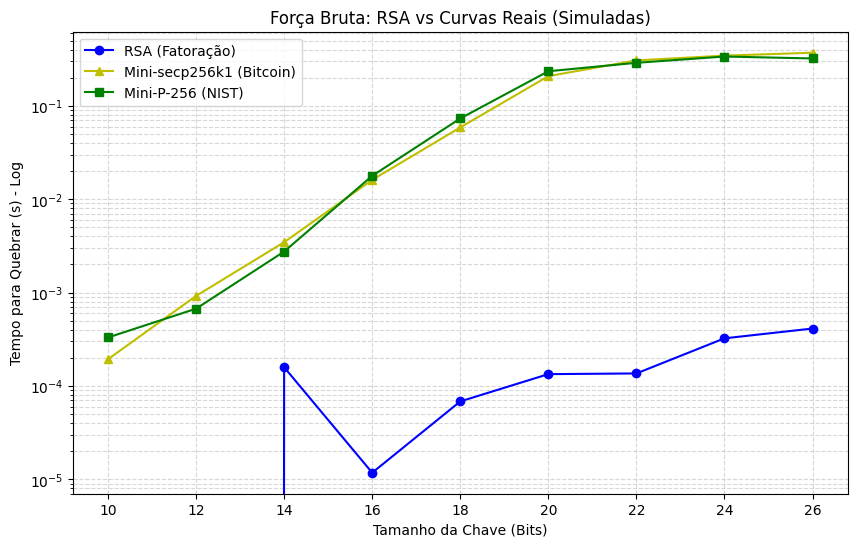

In [ ]:
import time
import random
import matplotlib.pyplot as plt

# "RSA" apenas a fatoração, que é a parte custosa do algoritmo.

def is_prime(n):
    if n < 2: return False
    if n == 2 or n == 3: return True
    if n % 2 == 0: return False
    for i in range(3, int(n**0.5) + 1, 2):
        if n % i == 0: return False
    return True

def generate_rsa_key(bits):
    target = 2**(bits // 2)
    def get_prime(target):
        while True:
            p = random.randint(target, 2*target)
            if is_prime(p): return p
    p = get_prime(target)
    q = get_prime(target)
    return p * q

def crack_rsa(n):
    start_time = time.time()
    limit = int(n**0.5) + 1
    for i in range(2, limit):
        if n % i == 0:
            return time.time() - start_time
    return time.time() - start_time

# Parte das curvas elpíticas 

class EllipticCurve:
    def __init__(self, a, b, p):
        self.a = a
        self.b = b
        self.p = p

    def add(self, p1, p2):
        if p1 is None: return p2
        if p2 is None: return p1
        x1, y1 = p1
        x2, y2 = p2
        
        if x1 == x2 and (y1 + y2) % self.p == 0: return None
        
        # Calcula a inclinação lambda. 

        if x1 == x2: 
            if y1 == 0: return None
            m = (3 * x1**2 + self.a) * pow(2 * y1, -1, self.p)
        else: 
            m = (y2 - y1) * pow(x2 - x1, -1, self.p)
        
        m = m % self.p
        x3 = (m**2 - x1 - x2) % self.p
        y3 = (m * (x1 - x3) - y1) % self.p
        return (x3, y3)

def find_generator(curve):
    # Encontra um ponto válido na curva para ser o gerador G
    for x in range(1, curve.p):
        rhs = (x**3 + curve.a * x + curve.b) % curve.p
        # Verifica se tem raiz quadrada (Critério de Euler)
        if pow(rhs, (curve.p - 1) // 2, curve.p) == 1:
            
            if curve.p % 4 == 3:
                y = pow(rhs, (curve.p + 1) // 4, curve.p)
                return (x, y)
    return None

def gen_ecc_key(bits, curve_type):
    # Gera um primo compatível com o tamanho de bits pedido
    while True:
        p = random.randint(2**(bits-1), 2**bits)
        if is_prime(p) and p % 4 == 3: break
    
    # Define os parâmetros baseados no tipo de curva real.
    if curve_type == 'secp256k1':
        # Bitcoin usa: a = 0, b = 7
        a, b = 0, 7
    elif curve_type == 'P-256':

        a, b = -3, 7 
    else:
        a, b = 2, 3 # Parâmetro genérico.

    curve = EllipticCurve(a, b, p)
    G = find_generator(curve)
    
    if G is None: return gen_ecc_key(bits, curve_type)

    # Gera chave privada d e pública Q
    d = random.randint(2, min(p-2, 5000000)) # A direita é um limitador para d.
    
    Q = None
    for bit in bin(d)[2:]:
        Q = curve.add(Q, Q)
        if bit == '1': Q = curve.add(Q, G)
            
    return curve, G, Q, d

# Logaritmo Discreto

def crack_ecc(curve, G, Q):
    start_time = time.time()
    current_P = G
    k = 1
    limit = 2000000 # Limite para tempo
    
    while current_P != Q:
        current_P = curve.add(current_P, G)
        k += 1
        if k > limit:
            return time.time() - start_time
            
    return time.time() - start_time

def run_benchmark():
    bits_range = [10, 12, 14, 16, 18, 20, 22, 24, 26]
    iterations = 100
    
    times_rsa = []
    times_secp = []
    times_nist = []
    
    print(f"{'BITS':<5} | {'RSA':<10} | {'secp256k1':<12} | {'NIST P-256':<12}")
    print("-" * 50)

    for b in bits_range:
        avg_rsa = 0
        avg_secp = 0
        avg_nist = 0
        
        for _ in range(iterations):
        
            n = generate_rsa_key(b)
            avg_rsa += crack_rsa(n)
            
            c1, g1, q1, _ = gen_ecc_key(b, 'secp256k1')
            avg_secp += crack_ecc(c1, g1, q1)
            
            c2, g2, q2, _ = gen_ecc_key(b, 'P-256')
            avg_nist += crack_ecc(c2, g2, q2)
            
        times_rsa.append(avg_rsa / iterations)
        times_secp.append(avg_secp / iterations)
        times_nist.append(avg_nist / iterations)
        
        print(f"{b:<5} | {times_rsa[-1]:.5f}    | {times_secp[-1]:.5f}      | {times_nist[-1]:.5f}")

    plt.figure(figsize=(10, 6))
    plt.plot(bits_range, times_rsa, 'bo-', label='RSA (Fatoração)')
    plt.plot(bits_range, times_secp, 'y^-', label='Mini-secp256k1 (Bitcoin)')
    plt.plot(bits_range, times_nist, 'gs-', label='Mini-P-256 (NIST)')
    
    plt.yscale('log')
    plt.title('Força Bruta: RSA vs Curvas Reais (Simuladas)')
    plt.xlabel('Tamanho da Chave (Bits)')
    plt.ylabel('Tempo para Quebrar (s) - Log')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.legend()
    plt.show()

if __name__ == "__main__":
    print("Iniciando Benchmark: RSA vs Estruturas de Curvas Reais...")
    print("Nota: Usamos equações reais (y^2=x^3+7 para secp) mas em corpos pequenos.\n")
    run_benchmark()